###**Model**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from tqdm import tqdm
from PIL import Image
import pickle
import torch
from torch import nn
from transformers import CLIPProcessor, CLIPModel
import os
from openai import OpenAI
from getpass import getpass

# Hide Warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip dataset
!cp /content/drive/MyDrive/dataset.zip /content/
with zipfile.ZipFile("/content/dataset.zip", "r") as z:
    files = z.infolist()

    for file in tqdm(files, desc="Extracting dataset"):     # Progress bar
        z.extract(file.filename, path="/content/dataset")

Extracting dataset: 100%|██████████| 1456/1456 [00:05<00:00, 260.20it/s]


In [ ]:
# Model
num_classes = 300
model = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes))

In [ ]:
# Load Model
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pt", map_location=device))
model = model.to(device)
model.eval()

Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=512, out_features=300, bias=True)
)

In [ ]:
# Clip Model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model = clip_model.to(device)
clip_model.eval()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
# Load Mapping
with open("/content/drive/MyDrive/answer_to_idx.pkl", "rb") as f:
    answer_to_idx = pickle.load(f)

idx_to_answer = {v: k for k, v in answer_to_idx.items()}

In [ ]:
# Load Datasets
train_df = pd.read_csv("/content/dataset/dataset/data_train.csv")
val_df = pd.read_csv("/content/dataset/dataset/data_eval.csv")

print(len(val_df))
print(val_df.head())

2494
                                     question  answer   image_id
0  what is the colour of the bag on the chair    pink   image399
1                 what is at the right bottom   table  image1341
2                  what are found on the rack     toy  image1320
3                     what is left of printer  mirror   image529
4            what is the colour of television   black   image201


In [ ]:
# Convert datasets to dataframe
train_df["image_path"] = "/content/dataset/dataset/images/" + train_df["image_id"] + ".png"
val_df["image_path"] = "/content/dataset/dataset/images/" + val_df["image_id"] + ".png"

val_df.head()

,question,answer,image_id,image_path
0,what is the colour of the bag on the chair,pink,image399,/content/dataset/dataset/images/image399.png
1,what is at the right bottom,table,image1341,/content/dataset/dataset/images/image1341.png
2,what are found on the rack,toy,image1320,/content/dataset/dataset/images/image1320.png
3,what is left of printer,mirror,image529,/content/dataset/dataset/images/image529.png
4,what is the colour of television,black,image201,/content/dataset/dataset/images/image201.png


In [ ]:
# Clean train answers
train_df["answers"] = train_df["answer"].apply(lambda x: [a.strip() for a in x.split(",")])

train_exp = train_df.explode("answers")

answer_freq = train_exp["answers"].value_counts()

In [ ]:
# Return the most frequent answer from a list
def pick_best_ans(ans_list):
    ans_list = [a.strip() for a in ans_list]
    return max(ans_list, key=lambda x: answer_freq.get(x, 0))

In [ ]:
train_df["answer"] = train_df["answers"].apply(pick_best_ans)
train_df = train_df.drop(columns=["answers"])

In [ ]:
# Clean validation answers
val_df["answers"] = val_df["answer"].apply(lambda x: [a.strip() for a in x.split(",")])

val_df["answer"] = val_df["answers"].apply(pick_best_ans)

val_df = val_df.drop(columns=["answers"])

In [ ]:
# Filter top answers
top_answers = train_df["answer"].value_counts().nlargest(300).index

train_df = train_df[train_df["answer"].isin(top_answers)]
val_df = val_df[val_df["answer"].isin(top_answers)]

In [ ]:
# Create a mapping from each answer to a unique index
answer_to_idx = {ans: i for i, ans in enumerate(top_answers)}

train_df["label"] = train_df["answer"].map(answer_to_idx)
val_df["label"] = val_df["answer"].map(answer_to_idx)

In [ ]:
# Fusion Function
def fuse_features(q_feat, img_feat):

    mul = q_feat * img_feat
    diff = torch.abs(q_feat - img_feat)

    fused = torch.cat([q_feat, img_feat, mul, diff], dim=1)

    return fused

In [ ]:
# Predict Function
def predict(image_path, question):

    # TEXT
    inputs_q = processor(
        text=[question],
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    inputs_q = {k: v.to(device) for k, v in inputs_q.items()}

    with torch.no_grad():
        q_feat_output = clip_model.get_text_features(**inputs_q)
        # Extract the tensor if the output is BaseModelOutputWithPooling
        q_feat = q_feat_output.pooler_output if hasattr(q_feat_output, 'pooler_output') else q_feat_output

    # IMAGE
    image = Image.open(image_path).convert("RGB")

    inputs_img = processor(images=[image], return_tensors="pt")
    inputs_img = {k: v.to(device) for k, v in inputs_img.items()}

    with torch.no_grad():
        img_feat_output = clip_model.get_image_features(**inputs_img)
        # Extract the tensor if the output is BaseModelOutputWithPooling
        img_feat = img_feat_output.pooler_output if hasattr(img_feat_output, 'pooler_output') else img_feat_output

    # FUSE
    x = fuse_features(q_feat, img_feat)

    # PREDICT
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1)

        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    answer = idx_to_answer[pred]

    # top3
    topk = torch.topk(probs, 3)
    top_answers = [idx_to_answer[i.item()] for i in topk.indices[0]]
    top_scores = [round(v.item(), 3) for v in topk.values[0]]

    return answer, confidence, top_answers, top_scores

In [ ]:
def show_demo(image_path, question):

    img = Image.open(image_path)

    answer, conf, top_ans, top_scores = predict(image_path, question)

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Q: {question}\n"
        f"A: {answer} ({conf:.2f})\n"
        f"Top3: {list(zip(top_ans, top_scores))}"
    )

    plt.show()

In [ ]:
# Load answer to index mapping and create index to answer mapping
with open("/content/drive/MyDrive/answer_to_idx.pkl", "rb") as f:
    answer_to_idx = pickle.load(f)

idx_to_answer = {v: k for k, v in answer_to_idx.items()}

###**LLM**

In [ ]:
# API


os.environ["OPENAI_API_KEY"] = getpass("Enter your API key:")
client = OpenAI()

Enter your API key:··········


In [ ]:
# LLM Function
def generate_llm_answer(question, answer, confidence):

    prompt = f"""
You are an AI assistant.

Answer the question naturally using the given short answer.

Question: {question}
Short Answer: {answer}

Write a short, natural sentence.
"""

    response = client.chat.completions.create(
        model="gpt-5",
        messages=[{"role": "user", "content": prompt}])

    return response.choices[0].message.content

In [ ]:
def get_true_answer(image_path, question):

    row = val_df[
        (val_df["image_path"] == image_path) &
        (val_df["question"] == question)
    ]

    if len(row) > 0:
        return row.iloc[0]["answer"]
    else:
        return "Not found"

In [ ]:
# Demo
import matplotlib.pyplot as plt
from PIL import Image

def demo(image_path, question):

    # Model Prediction
    answer, conf, top_ans, top_scores = predict(image_path, question)

    # LLM
    llm_answer = generate_llm_answer(question, answer, conf)

    true_answer = get_true_answer(image_path, question)

    # Show Image
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")

    # Title
    plt.title(
        f"Q: {question}\n"
        f"Model: {answer}\n"
        f"Top3: {list(zip(top_ans, top_scores))}")
    plt.show()

    # Print LLM

    if true_answer != "Not found":
        print("\n🤖 True Answer:")
        print(true_answer)

    print("\n🧠 LLM Answer:")
    print(llm_answer)

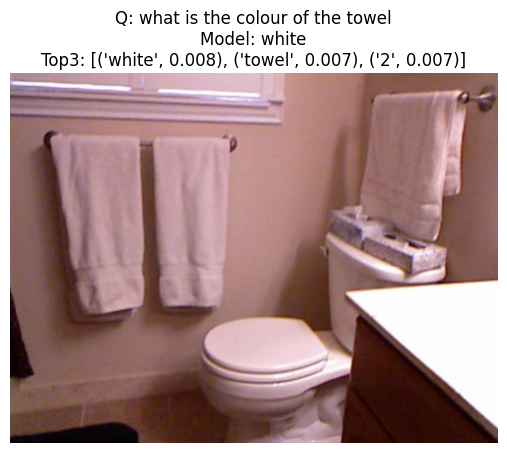


🤖 True Answer:
white

🧠 LLM Answer:
The towel is white.


In [ ]:
img_path = "/content/dataset/dataset/images/image694.png"
question = "what is the colour of the towel"

demo(img_path, question)

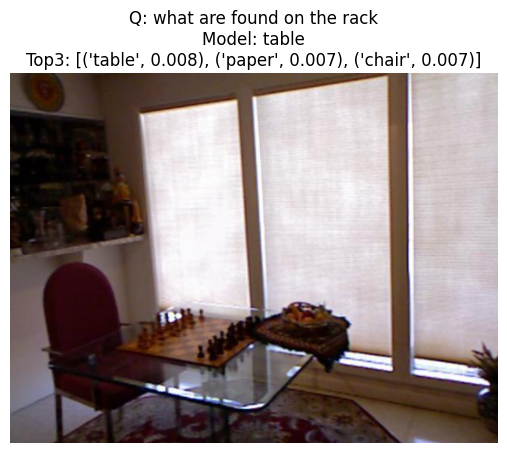


🤖 True Answer:
toy

🧠 LLM Answer:
There is a table on the rack.


In [ ]:
img_path = "/content/dataset/dataset/images/image1320.png"
question = "what are found on the rack"

demo(img_path, question)